### This notebook is to be run in a python environment without graph-tool. numba is necessary

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import gzip
import cmapPy.pandasGEXpress.parse as parse
from numba import jit
import pandas as pd


## Import the results of the 2500 optimizations, for forward and backward directions

- Different iterations of 2500 optimizations for the same value of $\lambda = .05 $
- Also get the magnitude of the $u_{opt}$ vector and the $R^2$

In [4]:


# Define the folder containing the u vector files


#folder_path = data_aa_lam_3/data'
folder_path = 'Validation/data_aa_lam_3/data'


# Initialize lists to store the data
uoptf = []
R2f = []
maguf = []

# Iterate over files in the folder
for filename in os.listdir(folder_path):
    if filename.startswith('uopt_forward'):
        # Extract indices from the filename using regular expressions
        match = re.match(r'uopt_forward_(\d+)_(\d+).npy', filename)
        if match:
            ind1, ind2 = map(int, match.groups())
            
            # Load uopt_forward file
            uopt_forward = np.load(os.path.join(folder_path, filename))
            uoptf.append(uopt_forward[6])
            
            # Load corresponding R2f file
            R2f_filename = f'R2f_{ind1}_{ind2}.npy'
            R2f_filepath = os.path.join(folder_path, R2f_filename)
            R2f_data = np.load(R2f_filepath)
            R2f.append(R2f_data)
            
            maguf_filename = f'magu_f_{ind1}_{ind2}.npy'
            maguf_filepath = os.path.join(folder_path, maguf_filename)
            maguf_data = np.load(maguf_filepath)
            maguf.append(maguf_data)
            
            
Af = np.asarray(uoptf)
            
# Initialize lists to store the data
uoptr = []
R2r = []
magur = []

# Iterate over files in the folder
for filename in os.listdir(folder_path):
    if filename.startswith('uopt_reverse'):
        # Extract indices from the filename using regular expressions
        match = re.match(r'uopt_reverse_(\d+)_(\d+).npy', filename)
        if match:
            ind1, ind2 = map(int, match.groups())
            
            # Load uopt_forward file
            uopt_reverse = np.load(os.path.join(folder_path, filename))
#             for i in range(len(uopt_reverse)):
            uoptr.append(uopt_reverse[6])
            
            # Load corresponding R2f file
            R2r_filename = f'R2r_{ind1}_{ind2}.npy'
            R2r_filepath = os.path.join(folder_path, R2r_filename)
            R2r_data = np.load(R2r_filepath)
            R2r.append(R2r_data)
            
            magur_filename = f'magu_r_{ind1}_{ind2}.npy'
            magur_filepath = os.path.join(folder_path, magur_filename)
            magur_data = np.load(magur_filepath)
            magur.append(magur_data)
           


        
Ar = np.asarray(uoptr)

Af

array([[ 1.15254814e-11,  2.33648602e-10,  1.94530042e-10, ...,
         3.55362607e-11,  1.89991731e-10,  5.98374652e-11],
       [ 1.14136194e-11,  1.59691380e-11,  1.61274868e-11, ...,
         4.70446675e-11,  3.38752557e-11,  1.61660351e-11],
       [ 9.59222801e-12, -1.16391889e-12,  2.58283990e-11, ...,
         1.96688522e-11,  2.91397573e-11,  8.49965959e-12],
       ...,
       [ 5.56479140e-12,  2.26940804e-12,  8.20126137e-12, ...,
         5.27056004e-12,  6.53569092e-12,  4.44308449e-12],
       [ 5.35833968e-11,  5.10923551e-11,  4.26875854e-11, ...,
         8.99274417e-11,  1.23610243e-10,  9.26804537e-11],
       [-1.86164485e-11, -4.36966568e-11, -3.47476199e-11, ...,
        -4.79116209e-11, -2.99090314e-11, -3.36933446e-11]],
      shape=(2500, 1225))

In [5]:
Af.shape

(2500, 1225)

Plots below are magnitudes and $R^2$ of various $u_{opt}$.

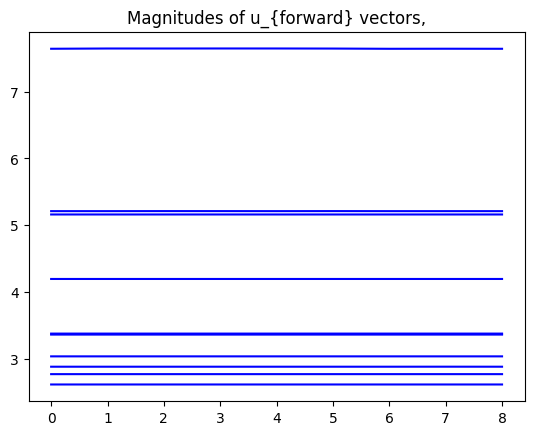

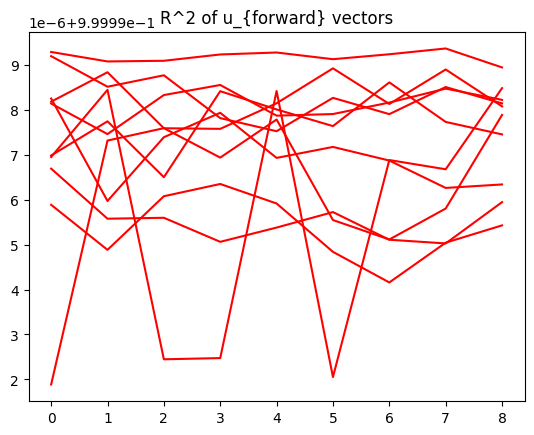

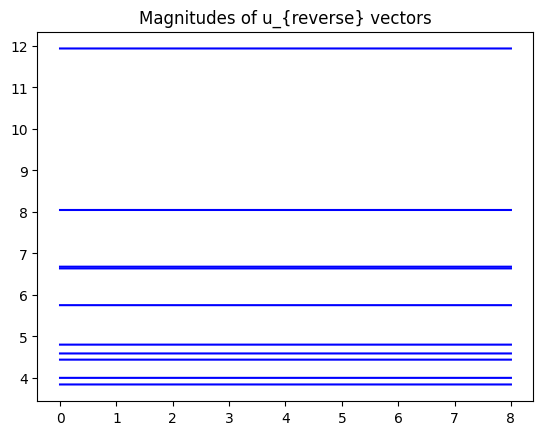

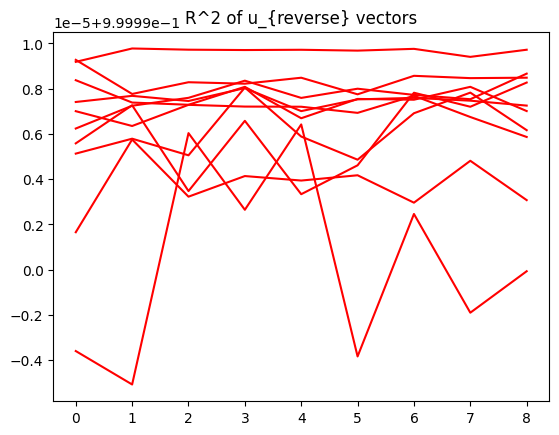

In [6]:
for i in range(10):
    plt.plot(maguf[i], 'b')
#     plt.plot(R2f[i], 'r')
plt.title(r'Magnitudes of u_{forward} vectors,')

plt.show()

for i in range(10):
#     plt.plot(maguf[i], 'b')
    plt.plot(R2f[i], 'r')
plt.title(r'R^2 of u_{forward} vectors')
plt.show()


for i in range(10):
    plt.plot(magur[i], 'b')
#     plt.plot(R2r[i], 'r')
plt.title(r'Magnitudes of u_{reverse} vectors')
plt.show()

for i in range(10):
#     plt.plot(magur[i], 'b')
    plt.plot(R2r[i], 'r')
plt.title(r'R^2 of u_{reverse} vectors')
plt.show()

Plot some of the $u_{opt}$ vectors

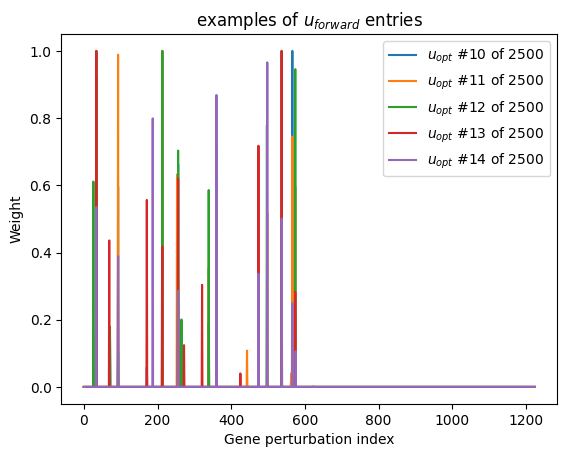

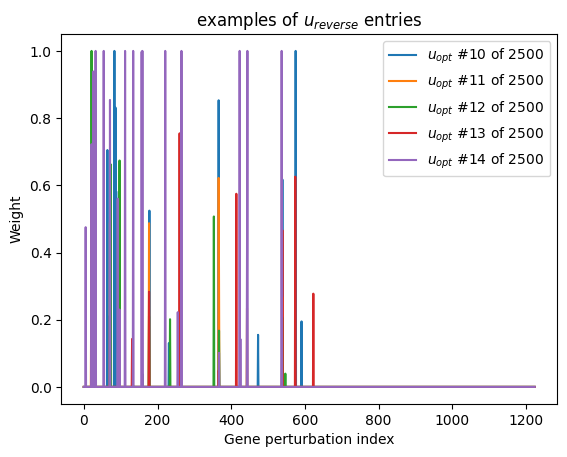

In [7]:
for i in range(10, 15):
    plt.plot(uoptf[i],label=r"$u_{opt}$ #" +str(i) + " of 2500")
    
plt.title(r'examples of $u_{forward}$ entries')
plt.xlabel('Gene perturbation index')
plt.ylabel('Weight')
plt.legend()
plt.show()

for i in range(10,15):
    plt.plot(uoptr[i],label=r"$u_{opt}$ #" +str(i) + " of 2500")
plt.title(r'examples of $u_{reverse}$ entries') #add title
plt.xlabel('Gene perturbation index')
plt.ylabel('Weight')
plt.legend()
plt.show()



The following files to be imported can be found in the google drive linked on the github.

The blocks below ensure the indices representing the perturbations in the A matrices and the B matrix match. We also want to ensure that the names of the perturbations are consistent.

In [8]:

Delta_gctx = parse.parse('gene_perturbations_for_ben.gctx')
#Delta_gctx.data_df

# Specify the path to the gzipped text file
file_path = 'mart_export.txt-2.gz'

# Open the gzipped file and read it into a DataFrame
with gzip.open(file_path, 'rt') as file:
    df_genenames = pd.read_csv(file, sep='\t')

# Display the DataFrame
print(df_genenames)


gene_dict = np.load('gene_pert_dict.npy', allow_pickle=True)
print(gene_dict)

matching_indices = np.load('matching_indices_asthma_rnaseq.npy')
disease_ind, gene_pert_ind = matching_indices[:,0], matching_indices[:,1]

gene_perts = Delta_gctx.row_metadata_df['fin_genotype']
for i in range(len(gene_perts)):
    print(i, gene_perts[i])
gene_perts[6] = 'NSD3'
gene_perts[9] = 'SLC25A25'
gene_perts[10] = 'SLC25A25'
gene_perts[11] = 'SLC25A25'
gene_perts[53] = 'EZH2'
gene_perts[54] = 'EZH2'
gene_perts[55] = 'EZH2'
gene_perts[56] = 'C9orf72'
gene_perts[57] = 'C9orf72'
gene_perts[59] = 'C9orf72'
gene_perts[60] = 'C9orf72'
gene_perts[67] = 'ERG'
gene_perts[68] = 'ERG'
gene_perts[71] = 'POU5F1'
gene_perts[119] = 'GATA2'
gene_perts[137] = 'NF1'
gene_perts[138] = 'AFF4'
gene_perts[141] = 'EGFR'
gene_perts[142] = 'ERG'
gene_perts[143] = 'GLIS3'
gene_perts[147] = 'NF1'
gene_perts[152] = 'SRRM2'
gene_perts[170] = 'U2AF1'
gene_perts[171] = 'U2AF1'
gene_perts[207] = 'EGFR'
gene_perts[208] = 'EGFR'
gene_perts[229] = 'ERG'
gene_perts[230] = 'ERG'
gene_perts[231] = 'ERG'
gene_perts[236] = 'SMAD1'
gene_perts[249] = 'ADAR'
gene_perts[250] = 'ADAR'
gene_perts[255] = 'ADAR'
gene_perts[256] = 'ADAR'
gene_perts[261] = 'ADAR'
gene_perts[262] = 'ADAR'
gene_perts[265] = 'PAN3'
gene_perts[266] = 'PAN3'
gene_perts[266] = 'PAN3'
gene_perts[277] = 'AFF4'
gene_perts[278] = 'UBE2O'
gene_perts[283] = 'CD28'
gene_perts[284] = 'CD86'
gene_perts[287] = 'CD28'
gene_perts[288] = 'CD86'
gene_perts[304] = 'TP53'
gene_perts[305] = 'TP53'
gene_perts[320] = 'NOTCH1'
gene_perts[321] = 'NOTCH1'
gene_perts[332] = 'G3BP1'
gene_perts[333] = 'G3BP1'
gene_perts[349] = 'YAP1'
gene_perts[350] = 'YAP1'
gene_perts[369] = 'TCF3'
gene_perts[370] = 'TCF3'
gene_perts[380] = 'PPP1CC'
gene_perts[381] = 'PPP1CC'
gene_perts[382] = 'PPP1CC'
gene_perts[387] = 'TUT4'
gene_perts[391] = 'TUT4'
gene_perts[396] = 'TUT4'
gene_perts[397] = 'TUT4'
gene_perts[414] = 'NR2F2'
gene_perts[415] = 'NR2F2'
gene_perts[438] = 'ELF1'
gene_perts[443] = 'GLIS3'
gene_perts[445] = 'TP53'
gene_perts[447] = 'ADARB1'
gene_perts[450] = 'ADARB1'
gene_perts[453] = 'CD86'
gene_perts[455] = 'SRRM2'
gene_perts[456] = 'SRRM2'
gene_perts[457] = 'SRRM2'
gene_perts[458] = 'SRRM2'
gene_perts[459] = 'SRRM3'
gene_perts[461] = 'SRRM4'
gene_perts[462] = 'SRRM4'
gene_perts[465] = 'KLF6'
gene_perts[473] = 'TENT4B'
gene_perts[474] = 'TENT4B'
gene_perts[480] = 'TENT4B'
gene_perts[481] = 'TENT4B'
gene_perts[485] = 'BRAF'
gene_perts[555] = 'AP1'
gene_perts[559] = 'CDK12'
gene_perts[582] = 'CCNF'
gene_perts[586] = 'BMPR2'
gene_perts[589] = 'BMPR2'
gene_perts[608] = 'MSI1'
gene_perts[609] = 'PCBP2'
gene_perts[621] = 'ERBB2'
gene_perts[624] = 'RNF43'
gene_perts[625] = 'RNF43'
gene_perts[629] = 'NF1'
gene_perts[630] = 'NF1'
gene_perts[631] = 'MBD5'
gene_perts[632] = 'MBD5'
gene_perts[633] = 'MBD5'
gene_perts[634] = 'MBD5'
gene_perts[635] = 'MBD5'
gene_perts[636] = 'MBD5'
gene_perts[644] = 'IRF1'
gene_perts[645] = 'IRF1'

/Users/budukaogonor/opt/anaconda3/envs/u_vec/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/Users/budukaogonor/opt/anaconda3/envs/u_vec/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


       Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Gene name,Gene Synonym
0       ENSG00000276191,ENSG00000276191.4,ENST00000632...                                                            
1       ENSG00000276191,ENSG00000276191.4,ENST00000617...                                                            
2       ENSG00000276191,ENSG00000276191.4,ENST00000616...                                                            
3       ENSG00000276191,ENSG00000276191.4,ENST00000633...                                                            
4       ENSG00000276191,ENSG00000276191.4,ENST00000616...                                                            
...                                                   ...                                                            
541863  ENSG00000288396,ENSG00000288396.1,ENST00000672...                                                            
541864  ENSG00000285065,ENSG00000285065.1,ENST00000643..

/var/folders/14/v69w202x4fj0jp687tj7bt680000gn/T/ipykernel_94301/1271528277.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(i, gene_perts[i])
/var/folders/14/v69w202x4fj0jp687tj7bt680000gn/T/ipykernel_94301/1271528277.py:24: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  gene_perts[6] = 'NSD3'
/var/folders/14/v69w202x4fj0jp687tj7bt680000gn/T/ipykernel_94301/1271528277.py:25: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = v

The upcoming code block introduces the direction (knockdown or overexpression) information.

In [9]:
kd_or_oe = Delta_gctx.row_metadata_df['sense'].values
gene_perts_ann = []
for i in range(len(kd_or_oe)):
    print(i,gene_perts[i], kd_or_oe[i][:2])
    gene_perts_ann.append(gene_perts[i] + ' '+kd_or_oe[i][:2])
gene_perts_ann

0 RPAP3 kd
1 RPAP3 kd
2 RPAP3 kd
3 HSPA5 kd
4 HSPA5 kd
5 NSD3 kd
6 NSD3 kd
7 WTAP kd
8 WTAP kd
9 SLC25A25 kd
10 SLC25A25 kd
11 SLC25A25 kd
12 BMI1 oe
13 DDX3X kd
14 DDX54 kd
15 TBX2 kd
16 MYCN kd
17 TBX2 kd
18 RNPS1 kd
19 RNPS1 oe
20 TP63 kd
21 TP63 kd
22 PROX1 oe
23 PROX1 kd
24 RNF40 kd
25 RNF40 kd
26 EDC4 kd
27 IKBKB kd
28 EDC4 kd
29 IKBKB kd
30 EDC4 kd
31 IKBKB kd
32 EDC4 kd
33 IKBKB kd
34 ARID1A kd
35 ARID1A kd
36 ARID1A kd
37 PAX8 kd
38 PAX8 kd
39 PAX8 kd
40 PAX8 kd
41 HDAC5 oe
42 HDAC5 oe
43 HDAC5 oe
44 HDAC5 oe
45 NR1D1 kd
46 SON kd
47 APOBEC3F oe
48 APOBEC3G oe
49 MYCN oe
50 NEAT1 kd
51 NEAT1 kd
52 EZH2 kd
53 EZH2 oe
54 EZH2 oe
55 EZH2 oe
56 C9orf72 mu
57 C9orf72 kd
58 INS mu
59 C9orf72 mu
60 C9orf72 kd
61 TRIM71 kd
62 STAU1 kd
63 STAU1 oe
64 TFEB kd
65 TFEB kd
66 ERG oe
67 ERG oe
68 ERG oe
69 METTL3 kd
70 WTAP kd
71 POU5F1 oe
72 METTL14 kd
73 METTL3 kd
74 VIRMA kd
75 WTAP kd
76 ADAR kd
77 ADAR kd
78 ADAR kd
79 ADAR kd
80 BEGAIN kd
81 CCNK kd
82 CDK10 kd
83 DPPA5 kd
84 EIF3L kd

/var/folders/14/v69w202x4fj0jp687tj7bt680000gn/T/ipykernel_94301/3051794303.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(i,gene_perts[i], kd_or_oe[i][:2])
/var/folders/14/v69w202x4fj0jp687tj7bt680000gn/T/ipykernel_94301/3051794303.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gene_perts_ann.append(gene_perts[i] + ' '+kd_or_oe[i][:2])


['RPAP3 kd',
 'RPAP3 kd',
 'RPAP3 kd',
 'HSPA5 kd',
 'HSPA5 kd',
 'NSD3 kd',
 'NSD3 kd',
 'WTAP kd',
 'WTAP kd',
 'SLC25A25 kd',
 'SLC25A25 kd',
 'SLC25A25 kd',
 'BMI1 oe',
 'DDX3X kd',
 'DDX54 kd',
 'TBX2 kd',
 'MYCN kd',
 'TBX2 kd',
 'RNPS1 kd',
 'RNPS1 oe',
 'TP63 kd',
 'TP63 kd',
 'PROX1 oe',
 'PROX1 kd',
 'RNF40 kd',
 'RNF40 kd',
 'EDC4 kd',
 'IKBKB kd',
 'EDC4 kd',
 'IKBKB kd',
 'EDC4 kd',
 'IKBKB kd',
 'EDC4 kd',
 'IKBKB kd',
 'ARID1A kd',
 'ARID1A kd',
 'ARID1A kd',
 'PAX8 kd',
 'PAX8 kd',
 'PAX8 kd',
 'PAX8 kd',
 'HDAC5 oe',
 'HDAC5 oe',
 'HDAC5 oe',
 'HDAC5 oe',
 'NR1D1 kd',
 'SON kd',
 'APOBEC3F oe',
 'APOBEC3G oe',
 'MYCN oe',
 'NEAT1 kd',
 'NEAT1 kd',
 'EZH2 kd',
 'EZH2 oe',
 'EZH2 oe',
 'EZH2 oe',
 'C9orf72 mu',
 'C9orf72 kd',
 'INS mu',
 'C9orf72 mu',
 'C9orf72 kd',
 'TRIM71 kd',
 'STAU1 kd',
 'STAU1 oe',
 'TFEB kd',
 'TFEB kd',
 'ERG oe',
 'ERG oe',
 'ERG oe',
 'METTL3 kd',
 'WTAP kd',
 'POU5F1 oe',
 'METTL14 kd',
 'METTL3 kd',
 'VIRMA kd',
 'WTAP kd',
 'ADAR kd',
 'ADA

In [10]:

# Create a dictionary to store the renumbered gene perturbations
renumbered_gene_perts = {}
new_index = 0

# Iterate through the list and populate the dictionary
for i, gene in enumerate(gene_perts_ann):
    if gene not in renumbered_gene_perts:
        renumbered_gene_perts[gene] = {"new_index": new_index, "original_indices": []}
        new_index += 1
    renumbered_gene_perts[gene]["original_indices"].append(i)

# Print the renumbered gene perturbations dictionary
for gene, info in renumbered_gene_perts.items():
    print(f"{info['new_index']}: {gene} -> Original indices: {info['original_indices']}")

0: RPAP3 kd -> Original indices: [0, 1, 2]
1: HSPA5 kd -> Original indices: [3, 4, 466]
2: NSD3 kd -> Original indices: [5, 6]
3: WTAP kd -> Original indices: [7, 8, 70, 75]
4: SLC25A25 kd -> Original indices: [9, 10, 11]
5: BMI1 oe -> Original indices: [12]
6: DDX3X kd -> Original indices: [13, 704, 1026]
7: DDX54 kd -> Original indices: [14]
8: TBX2 kd -> Original indices: [15, 17]
9: MYCN kd -> Original indices: [16, 223]
10: RNPS1 kd -> Original indices: [18]
11: RNPS1 oe -> Original indices: [19]
12: TP63 kd -> Original indices: [20, 21, 441]
13: PROX1 oe -> Original indices: [22]
14: PROX1 kd -> Original indices: [23, 219]
15: RNF40 kd -> Original indices: [24, 25]
16: EDC4 kd -> Original indices: [26, 28, 30, 32]
17: IKBKB kd -> Original indices: [27, 29, 31, 33]
18: ARID1A kd -> Original indices: [34, 35, 36]
19: PAX8 kd -> Original indices: [37, 38, 39, 40]
20: HDAC5 oe -> Original indices: [41, 42, 43, 44]
21: NR1D1 kd -> Original indices: [45]
22: SON kd -> Original indices:

Some perturbations have multiple perturbations associated with them. Here we combine the experiments for a given perturbation by averaging the responses.

In [11]:


# Assuming Delta_gctx.data_df and gene_perts_ann are already defined

#this matrix A is the matrix referred to as B in the main text
A = Delta_gctx.data_df.to_numpy()



# Create a dictionary to store the renumbered gene perturbations
renumbered_gene_perts = {}
new_index = 0

# Iterate through the list and populate the dictionary
for i, gene in enumerate(gene_perts_ann):
    if gene not in renumbered_gene_perts:
        renumbered_gene_perts[gene] = {"new_index": new_index, "original_indices": []}
        new_index += 1
    renumbered_gene_perts[gene]["original_indices"].append(i)

# Print the renumbered gene perturbations dictionary
for gene, info in renumbered_gene_perts.items():
    print(f"{info['new_index']}: {gene} -> Original indices: {info['original_indices']}")

# Create the new matrix with averaged rows
num_genes = len(renumbered_gene_perts)
num_cols = A.shape[1]
A_new = np.zeros((num_genes, num_cols))

# Populate the new matrix with averages
for gene, info in renumbered_gene_perts.items():
    indices = info["original_indices"]
    averaged_row = np.mean(A[indices, :], axis=0)
    A_new[info["new_index"], :] = averaged_row

# Print the new matrix
print("\nNew matrix A_new with averaged rows:")
print(A_new)
#np.save('A_new.npy', A_new)

# Create a new condensed list of gene perturbations
condensed_gene_perts = [None] * num_genes
for gene, info in renumbered_gene_perts.items():
    condensed_gene_perts[info["new_index"]] = gene

# Print the new condensed list of gene perturbations
print("\nCondensed list of gene perturbations:")
print(condensed_gene_perts)

# Create the new Ar and Af matrices
num_rows = Ar.shape[0]
num_new_cols = len(renumbered_gene_perts)
Ar_new = np.zeros((num_rows, num_new_cols))
Af_new = np.zeros((num_rows, num_new_cols))

# Populate the new Ar and Af matrices
for gene, info in renumbered_gene_perts.items():
    indices = info["original_indices"]
    for i in range(num_rows):
        sum_Ar = np.sum(Ar[i, indices])
        sum_Af = np.sum(Af[i, indices])
        Ar_new[i, info["new_index"]] = min(sum_Ar, 1)
        Af_new[i, info["new_index"]] = min(sum_Af, 1)

# Print the new Ar and Af matrices
print("\nNew Ar matrix with summed and clipped rows:")
print(Ar_new)
print("\nNew Af matrix with summed and clipped rows:")
print(Af_new)

# Save the new Ar and Af matrices
#np.save('Ar_new.npy', Ar_new)
#np.save('Af_new.npy', Af_new)


0: RPAP3 kd -> Original indices: [0, 1, 2]
1: HSPA5 kd -> Original indices: [3, 4, 466]
2: NSD3 kd -> Original indices: [5, 6]
3: WTAP kd -> Original indices: [7, 8, 70, 75]
4: SLC25A25 kd -> Original indices: [9, 10, 11]
5: BMI1 oe -> Original indices: [12]
6: DDX3X kd -> Original indices: [13, 704, 1026]
7: DDX54 kd -> Original indices: [14]
8: TBX2 kd -> Original indices: [15, 17]
9: MYCN kd -> Original indices: [16, 223]
10: RNPS1 kd -> Original indices: [18]
11: RNPS1 oe -> Original indices: [19]
12: TP63 kd -> Original indices: [20, 21, 441]
13: PROX1 oe -> Original indices: [22]
14: PROX1 kd -> Original indices: [23, 219]
15: RNF40 kd -> Original indices: [24, 25]
16: EDC4 kd -> Original indices: [26, 28, 30, 32]
17: IKBKB kd -> Original indices: [27, 29, 31, 33]
18: ARID1A kd -> Original indices: [34, 35, 36]
19: PAX8 kd -> Original indices: [37, 38, 39, 40]
20: HDAC5 oe -> Original indices: [41, 42, 43, 44]
21: NR1D1 kd -> Original indices: [45]
22: SON kd -> Original indices:


New matrix A_new with averaged rows:
[[ 1.18364794e-02  3.48673433e-01 -7.93549061e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.80215642e-01 -2.09911242e-01 -1.29883587e+00 ... -2.60893494e-01
   0.00000000e+00  0.00000000e+00]
 [-1.70666769e-01 -4.58774567e-02 -2.52611488e-01 ...  2.97458982e-03
   0.00000000e+00  0.00000000e+00]
 ...
 [-8.83023068e-03 -2.57957801e-02  7.14475522e-03 ... -5.00418283e-02
   2.28287354e-02  3.10613457e-02]
 [-5.96420094e-03 -2.27638111e-02  7.40177045e-03 ... -4.52152826e-02
   2.08722726e-02  2.87033860e-02]
 [-1.28285226e-03 -3.25036868e-02  6.73896680e-03 ... -6.14917614e-02
   2.76486054e-02  3.69331166e-02]]

Condensed list of gene perturbations:
['RPAP3 kd', 'HSPA5 kd', 'NSD3 kd', 'WTAP kd', 'SLC25A25 kd', 'BMI1 oe', 'DDX3X kd', 'DDX54 kd', 'TBX2 kd', 'MYCN kd', 'RNPS1 kd', 'RNPS1 oe', 'TP63 kd', 'PROX1 oe', 'PROX1 kd', 'RNF40 kd', 'EDC4 kd', 'IKBKB kd', 'ARID1A kd', 'PAX8 kd', 'HDAC5 oe', 'NR1D1 kd', 'SON kd', 'APOBEC3F oe', '


New Ar matrix with summed and clipped rows:
[[-1.57504663e-12 -1.08158888e-12  1.92338890e-13 ... -4.96116573e-13
  -6.81515671e-13 -3.66057292e-13]
 [-1.90603840e-10 -9.87604722e-11 -5.26268273e-11 ... -7.86311879e-11
  -4.51855921e-11 -4.84801713e-11]
 [ 5.71232227e-10  4.68122464e-10  3.27990461e-10 ...  2.74092649e-10
   1.89989572e-10  2.51341991e-10]
 ...
 [-1.94575402e-10 -1.04102445e-10 -5.15666131e-11 ... -9.39875464e-11
  -8.23427009e-11 -2.60916870e-11]
 [ 5.23289117e-12  7.95607378e-12  3.14223422e-12 ...  5.82985590e-12
   6.94594703e-13  6.54710589e-12]
 [ 5.62653637e-11  4.19022171e-11 -3.50598429e-12 ...  3.53799644e-11
   1.61798416e-11  1.96790397e-11]]

New Af matrix with summed and clipped rows:
[[ 4.39704126e-10  5.18620992e-10 -5.30365073e-12 ...  1.78220007e-10
   1.57892962e-10  3.55362607e-11]
 [ 4.35102442e-11  7.75268836e-11  3.02624996e-11 ...  3.75961655e-11
   1.14364745e-11  4.70446675e-11]
 [ 3.42567081e-11  3.20143999e-11  6.47906095e-11 ...  4.1340431

Text(0, 0.5, 'weight')

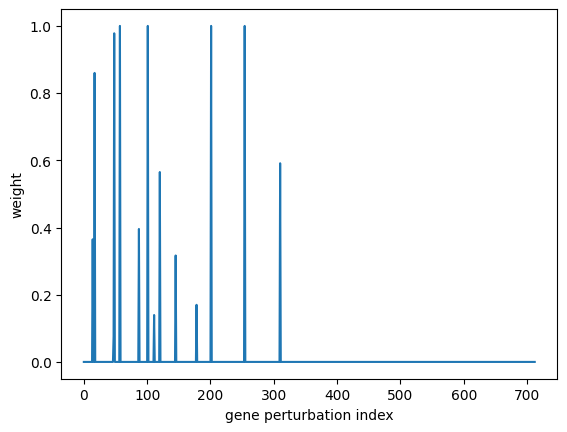

In [12]:
plt.plot(Ar_new[1]) #show first u vector
plt.xlabel('gene perturbation index')
plt.ylabel('weight')

In [30]:
Ar, Af = Ar_new, Af_new #set new matrices to old variables

In [31]:
Ar.shape

(2500, 713)

In [32]:


# Define a function to set elements close to zero to zero
def set_close_to_zero(arr, tol=1e-6):
    arr[np.abs(arr) < tol] = 0
    return arr

# Define a function to remove rows and columns that sum to zero
def remove_zero_rows_columns(arr):
    row_sum = np.sum(arr, axis=1)
    col_sum = np.sum(arr, axis=0)
    non_zero_rows = np.where(row_sum != 0)[0]
    non_zero_cols = np.where(col_sum != 0)[0]
    return arr[non_zero_rows][:, non_zero_cols], non_zero_rows, non_zero_cols

# Set elements close to zero to zero
Af = set_close_to_zero(Af)

# Remove rows and columns that sum to zero
Af, non_zero_rows_f, non_zero_cols_f = remove_zero_rows_columns(Af)


Ar = set_close_to_zero(Ar)

# Remove rows and columns that sum to zero
Ar, non_zero_rows_r, non_zero_cols_r = remove_zero_rows_columns(Ar)

print("Af after processing:")
print(Af)


Af after processing:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.15133351]]


### Compare to minimal entropy graph, get $\beta_i, \gamma_i, p_{ij}$ from eq 16.

In [38]:

@jit(nopython=True)
def get_beta_i_gamma_j(A):
#     A is an adjacency matrix 
    iters = 200
    beta, gamma, beta_new, gamma_new  = np.ones(np.shape(A)[0]), \
    np.ones(np.shape(A)[1]), np.ones(np.shape(A)[0]), np.ones(np.shape(A)[1])
    
    k_row, k_col = np.sum(A, axis=1), np.sum(A, axis=0) #degrees of the rows and columns of matrix A
    
    for iteration in range(iters):
        rij = np.zeros((len(beta), len(gamma)))
        for i in range(len(beta)):
            for j in range(len(gamma)):
                rij[i][j] = 1/(np.exp(-gamma[j]) + np.exp(beta[i]))
            beta_new[i] =  np.log(k_row[i])-np.log(np.sum(rij[i]))
        rij = np.zeros((len(gamma), len(beta)))
        for i in range(len(gamma)):
            for j in range(len(beta)):
                rij[i][j] = 1/(np.exp(-beta[j]) + np.exp(gamma[i]))
            gamma_new[i] =  np.log(k_col[i])-np.log(np.sum(rij[i]))
         
        beta, gamma = beta_new, gamma_new

    
    pij = np.zeros(np.shape(A))
    for i in range(np.shape(A)[0]):
        for j in range(np.shape(A)[1]):
            pij[i][j] = 1/(1+np.exp(-(beta[i]+gamma[j])))
        
                                        
    return beta, gamma, pij
                                                    
beta_f, gamma_f, pij_f = get_beta_i_gamma_j(Af)
beta_r, gamma_r, pij_r = get_beta_i_gamma_j(Ar)



In [39]:
k_row, k_col = np.sum(Af, axis=1), np.sum(Af, axis=0)
k_row_ij, k_col_ij = np.sum(pij_f, axis=1), np.sum(pij_f, axis=0)
print(k_row[0:10])
print(k_row_ij[0:10])
print(k_col[0:10])
print(k_col_ij[0:10])

[3.5665516  3.66715477 5.90291245 5.6504634  6.07020766 3.4973829
 6.51528895 6.99930035 7.34581438 4.55564161]
[3.5665516  3.66715477 5.90291245 5.6504634  6.07020766 3.4973829
 6.51528895 6.99930035 7.34581438 4.55564161]
[2.14991194e+01 1.87824338e+01 1.70168357e+01 1.13253206e+01
 8.08585770e-01 3.06095217e+02 4.57027851e+01 3.09887042e+02
 4.03552750e+00 1.01303359e+03]
[2.14991194e+01 1.87824338e+01 1.70168357e+01 1.13253206e+01
 8.08585770e-01 3.06095217e+02 4.57027851e+01 3.09887042e+02
 4.03552750e+00 1.01303359e+03]


In [40]:
@jit(nopython=True)
def get_Aij_pij(Af, Ar, pij_f, pij_r):
    Aij_f = np.zeros((len(Af[0]), len(Af[0])))
    for i in range(len(Af[0])):
        for j in range(len(Af[0])):
            Aij_f[i][j] = Af[:,i]@Af[:,j]


    pij_pair_f = np.zeros((len(pij_f[0]), len(pij_f[0])))
    err_pij_pair_f = np.zeros((len(pij_f[0]), len(pij_f[0])))

    NNf = len(pij_f[:,0])
    Aij_f = Aij_f/NNf

    for i in range(len(pij_f[0])):
        for j in range(len(pij_f[0])):
            pij_pair_f[i][j] = pij_f[:,i]@pij_f[:,j]/NNf
            if pij_pair_f[i][j] > 0.:
                err_pij_pair_f[i][j] = np.sum(pij_f[:,i]**2.*pij_f[:,j]*(1-pij_f[:,j]) +\
                                              pij_f[:,j]**2.*pij_f[:,i]*(1-pij_f[:,i]))**.5/NNf
 

    Aij_r = np.zeros((len(Ar[0]), len(Ar[0])))
    for i in range(len(Ar[0])):
        for j in range(len(Ar[0])):
            Aij_r[i][j] = Ar[:,i]@Ar[:,j]


    pij_pair_r = np.zeros((len(pij_r[0]), len(pij_r[0])))
    err_pij_pair_r = np.zeros((len(pij_r[0]), len(pij_r[0])))

    NNr = len(pij_r[:,0])
    Aij_r = Aij_r/NNf

    for i in range(len(pij_r[0])):
        for j in range(len(pij_r[0])):
            pij_pair_r[i][j] = pij_r[:,i]@pij_r[:,j]/NNr
            if pij_pair_r[i][j] > 0.:
                err_pij_pair_r[i][j] = np.sum(pij_r[:,i]**2.*pij_r[:,j]*(1-pij_r[:,j]) +\
                                              pij_r[:,j]**2.*pij_r[:,i]*(1-pij_r[:,i]))**.5/NNr
        
        
    return Aij_f, Aij_r, pij_pair_f, pij_pair_r, err_pij_pair_f, err_pij_pair_r
    
Aij_f, Aij_r, pij_pair_f, pij_pair_r, err_pij_pair_f, err_pij_pair_r = get_Aij_pij(Af, Ar, pij_f, pij_r)
    
    

/var/folders/14/v69w202x4fj0jp687tj7bt680000gn/T/ipykernel_71957/3822440533.py:17: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  pij_pair_f[i][j] = pij_f[:,i]@pij_f[:,j]/NNf


In [52]:
np.save('pij_pair_f',pij_pair_f)
np.save('pij_pair_r',pij_pair_r)
np.save('err_pij_pair_f',err_pij_pair_f)
np.save('err_pij_pair_r',err_pij_pair_r)
np.save('Aij_f',Aij_f)
np.save('Aij_r',Aij_r)

np.save('non_zero_cols_r',non_zero_cols_r)

np.save('non_zero_cols_f',non_zero_cols_f)
np.save('condensed_gene_perts',condensed_gene_perts)

pert_column_ids = Delta_gctx.data_df.columns
np.save('pert_column_ids',pert_column_ids)
np.save('A_new.npy', A_new)
gene_perts.to_csv('gene_perts')

The results of the previous cell will be further used in the network analysis notebook, which requires graph-tool. In the meantime, we can generate figure 5c:

### Create fig 5c

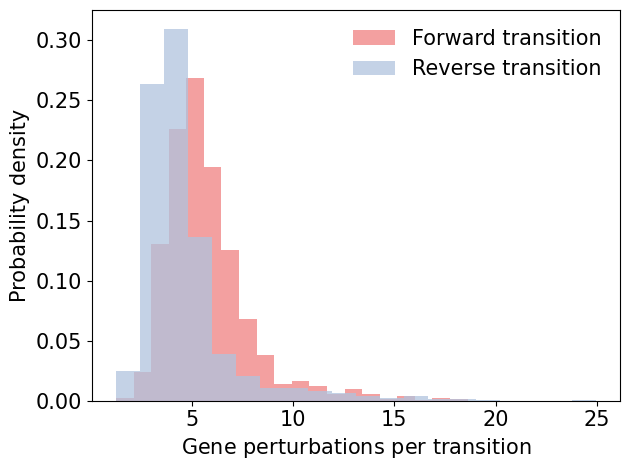

In [42]:
plt.hist(np.sum(Af, axis=1), 20, density=True, alpha=0.75, label='Forward transition', color = 'lightcoral')
plt.hist(np.sum(Ar, axis=1), 20, density=True, alpha=0.75, label='Reverse transition', color = 'lightsteelblue')

# Set x and y labels
plt.xlabel(r'$\mathrm{Gene~perturbations~per~transition}$', fontsize=15)
plt.ylabel('Probability density', fontsize=15)

# Set tick parameters
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Show legend
plt.legend(fontsize=15,frameon=False)
plt.tight_layout()
plt.savefig('fig3c.pdf')
# Display the plot
# plt.tight_layout()
plt.show()
